In [3]:
! pip install "chronos-forecasting>=2.0" "pandas[pyarrow]" --quiet

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Chronos
import time
import warnings
warnings.filterwarnings('ignore')

from chronos import Chronos2Pipeline

In [5]:
BASE = Path.cwd() / 'data' / 'processed'
df = pd.read_parquet(BASE / 'dataset_consolidado.parquet')
df.index = pd.to_datetime(df.index)
df.index.name = 'timestamp'

# Train/test
train = df[df.index < '2025-07-13']
test = df[df.index >= '2025-07-13']

covariables = ['gen_termica', 'ONI', 'aportes_energia_gwh']
ID_SERIE = 'precio_bolsa'  # identificador único de la serie

print(f"Train: {train.index.min().date()} → {train.index.max().date()} ({len(train)} días)")
print(f"Test:  {test.index.min().date()} → {test.index.max().date()} ({len(test)} días)")

Train: 2013-01-01 → 2025-07-12 (4576 días)
Test:  2025-07-13 → 2026-05-01 (293 días)


In [6]:
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")  # usar "cpu" si no hay GPU

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

# Predicción univariante en test

In [7]:
horizonte_test = len(test)

context_df_uni = (
    train[['precio_bolsa']]
    .reset_index()
    .assign(id=ID_SERIE)
)

t0 = time.time()
pred_df_uni = pipeline.predict_df(
    context_df_uni,
    prediction_length=horizonte_test,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target="precio_bolsa",
)
tt_uni = time.time() - t0

pred_df_uni = pred_df_uni.set_index("timestamp")
pred_chronos_uni = pred_df_uni["predictions"]  # punto (media)
p10_uni = pred_df_uni["0.1"]
p90_uni = pred_df_uni["0.9"]

print(pred_df_uni.head())

                      id   target_name  predictions         0.1         0.5  \
timestamp                                                                     
2025-07-13  precio_bolsa  precio_bolsa   117.422363  110.614624  117.422363   
2025-07-14  precio_bolsa  precio_bolsa   137.009201  121.015259  137.009201   
2025-07-15  precio_bolsa  precio_bolsa   147.363190  125.286865  147.363190   
2025-07-16  precio_bolsa  precio_bolsa   153.380005  123.573151  153.380005   
2025-07-17  precio_bolsa  precio_bolsa   146.603729  118.555481  146.603729   

                   0.9  
timestamp               
2025-07-13  137.397202  
2025-07-14  177.626556  
2025-07-15  198.381073  
2025-07-16  220.133163  
2025-07-17  225.925568  


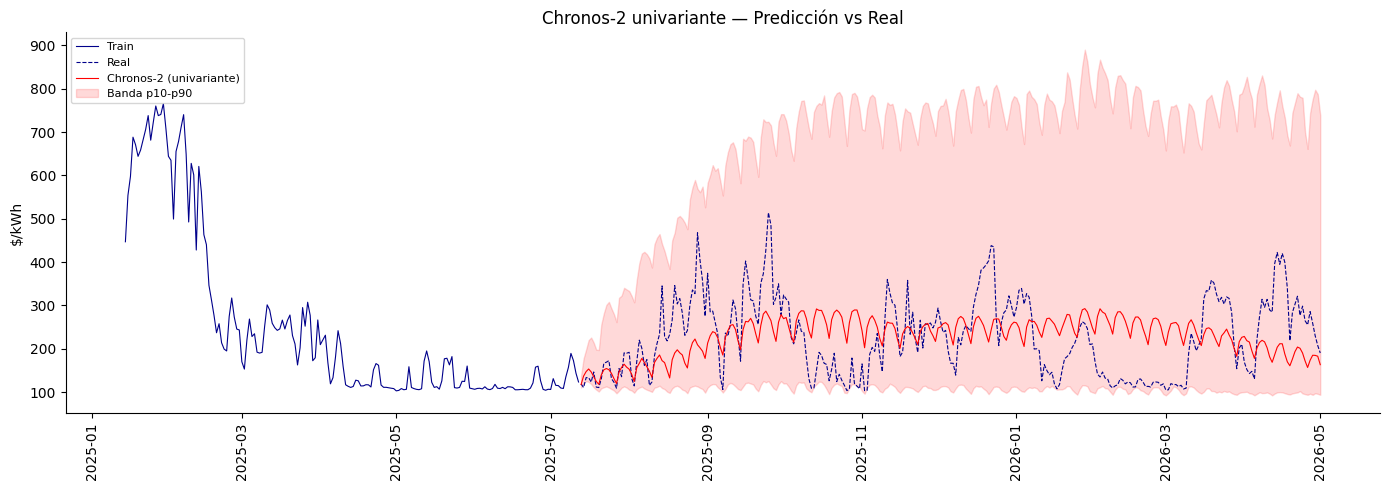

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-180:], train['precio_bolsa'][-180:], color='darkblue', linewidth=0.8, label='Train')
ax.plot(test.index, test['precio_bolsa'], color='darkblue', linewidth=0.8, linestyle='--', label='Real')
ax.plot(pred_chronos_uni.index, pred_chronos_uni, color='red', linewidth=0.8, label='Chronos-2 (univariante)')
ax.fill_between(pred_df_uni.index, p10_uni, p90_uni, color='red', alpha=0.15, label='Banda p10-p90')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('Chronos-2 univariante — Predicción vs Real')
sns.despine()
plt.tight_layout()
plt.show()

# Predicción con covariables sobre Test

In [9]:
context_df_cov = (
    train[['precio_bolsa'] + covariables]
    .reset_index()
    .assign(id=ID_SERIE)
)

future_df_cov = (
    test[covariables]
    .reset_index()
    .assign(id=ID_SERIE)
)

t0 = time.time()
pred_df_cov = pipeline.predict_df(
    context_df_cov,
    future_df=future_df_cov,
    prediction_length=horizonte_test,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target="precio_bolsa",
)
tt_cov = time.time() - t0

pred_df_cov = pred_df_cov.set_index("timestamp")
pred_chronos_cov = pred_df_cov["predictions"]

print(pred_df_cov.head())

                      id   target_name  predictions         0.1         0.5  \
timestamp                                                                     
2025-07-13  precio_bolsa  precio_bolsa   121.925980  108.179520  121.925980   
2025-07-14  precio_bolsa  precio_bolsa   137.034409  116.138611  137.034409   
2025-07-15  precio_bolsa  precio_bolsa   150.681839  123.838043  150.681839   
2025-07-16  precio_bolsa  precio_bolsa   158.945175  125.829727  158.945175   
2025-07-17  precio_bolsa  precio_bolsa   153.607956  121.338699  153.607956   

                   0.9  
timestamp               
2025-07-13  141.034561  
2025-07-14  171.304413  
2025-07-15  191.833588  
2025-07-16  207.046753  
2025-07-17  208.617981  


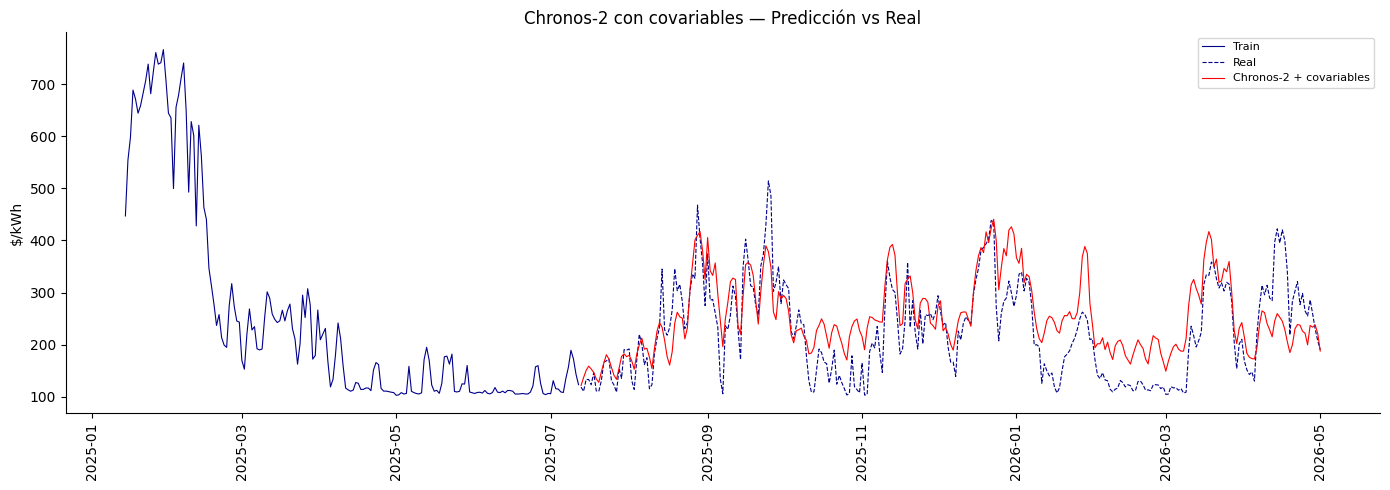

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-180:], train['precio_bolsa'][-180:], color='darkblue', linewidth=0.8, label='Train')
ax.plot(test.index, test['precio_bolsa'], color='darkblue', linewidth=0.8, linestyle='--', label='Real')
ax.plot(pred_chronos_cov.index, pred_chronos_cov, color='red', linewidth=0.8, label='Chronos-2 + covariables')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('Chronos-2 con covariables — Predicción vs Real')
sns.despine()
plt.tight_layout()
plt.show()

## Métricas (MASE, RMSSE, MAE, RMSE, MAPE, SMAPE, R2, TT)

In [11]:
def calcular_metricas(real, pred, serie_contexto, m=7, tt_sec=None): # Estacionalidad semanal (m=7)
    real = np.asarray(real, dtype=float)
    pred = np.asarray(pred, dtype=float)

    error = real - pred
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    mape = np.mean(np.abs(error / real)) * 100
    smape = np.mean(np.abs(error) / ((np.abs(real) + np.abs(pred)) / 2)) * 100

    ss_res = np.sum(error ** 2)
    ss_tot = np.sum((real - np.mean(real)) ** 2)
    r2 = 1 - ss_res / ss_tot

    # Escalamiento con un naive estacional de periodo m sobre el contexto (train)
    naive_diff = np.abs(np.diff(serie_contexto, n=1)) if m == 1 else np.abs(
        np.asarray(serie_contexto[m:]) - np.asarray(serie_contexto[:-m])
    )
    escala_mae = np.mean(naive_diff)
    escala_rmse = np.sqrt(np.mean(naive_diff ** 2))

    mase = mae / escala_mae
    rmsse = rmse / escala_rmse

    return {
        'MASE': round(mase, 3),
        'RMSSE': round(rmsse, 3),
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE': round(mape, 2),
        'SMAPE': round(smape, 2),
        'R2': round(r2, 3),
        'TT (Sec)': round(tt_sec, 2) if tt_sec is not None else None,
    }

In [12]:
real = test['precio_bolsa']
serie_contexto = train['precio_bolsa'].values
resultados_chronos = {}

resultados_chronos['Chronos-2 (univariante)'] = calcular_metricas(
    real, pred_chronos_uni.values, serie_contexto=serie_contexto, m=7, tt_sec=tt_uni
)
resultados_chronos['Chronos-2 + covariables'] = calcular_metricas(
    real, pred_chronos_cov.values, serie_contexto=serie_contexto, m=7, tt_sec=tt_cov
)

print(f"Precio promedio test: {real.mean():.2f} $/kWh\n")
tabla_metricas = pd.DataFrame(resultados_chronos).T
tabla_metricas = tabla_metricas[['MASE', 'RMSSE', 'MAE', 'RMSE', 'MAPE', 'SMAPE', 'R2', 'TT (Sec)']]
tabla_metricas

Precio promedio test: 225.93 $/kWh



,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
Chronos-2 (univariante),1.167,0.701,78.89,96.02,42.30,35.12,-0.140,0.76
Chronos-2 + covariables,0.776,0.467,52.45,64.02,28.96,24.23,0.493,0.27


# Predicción a un horizonte futuro

## Univariante:

In [13]:
horizonte_futuro = 30  # días a pronosticar

context_df_futuro_uni = (
    df[['precio_bolsa']]
    .reset_index()
    .assign(id=ID_SERIE)
)

pred_df_futuro_uni = pipeline.predict_df(
    context_df_futuro_uni,
    prediction_length=horizonte_futuro,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target="precio_bolsa",
).set_index("timestamp")

df_forecast_futuro = pred_df_futuro_uni.rename(columns={
    'predictions': 'Punto', '0.1': 'p10', '0.9': 'p90'
})[['Punto', 'p10', 'p90']]

print(df_forecast_futuro)

                 Punto         p10         p90
timestamp                                     
2026-05-02  163.655182  146.152863  201.146118
2026-05-03  152.213455  128.628006  201.017853
2026-05-04  169.079193  130.577621  238.927017
2026-05-05  183.565338  132.467010  270.488617
2026-05-06  182.349426  126.323242  277.810089
2026-05-07  178.990631  122.314377  289.324646
2026-05-08  173.399048  115.851624  285.603668
2026-05-09  157.718704  107.282822  275.243408
2026-05-10  148.564438  103.757919  264.642944
2026-05-11  165.735977  107.095047  295.461121
2026-05-12  178.560425  114.082047  319.118439
2026-05-13  179.959946  113.469269  329.845673
2026-05-14  179.953079  110.328491  331.730682
2026-05-15  172.854721  107.183670  329.352905
2026-05-16  159.488983  102.185089  308.868927
2026-05-17  146.039429   98.603012  295.983582
2026-05-18  154.292267  105.506393  319.636719
2026-05-19  165.207840  107.913239  340.919617
2026-05-20  164.496185  107.468842  342.026794
2026-05-21  1

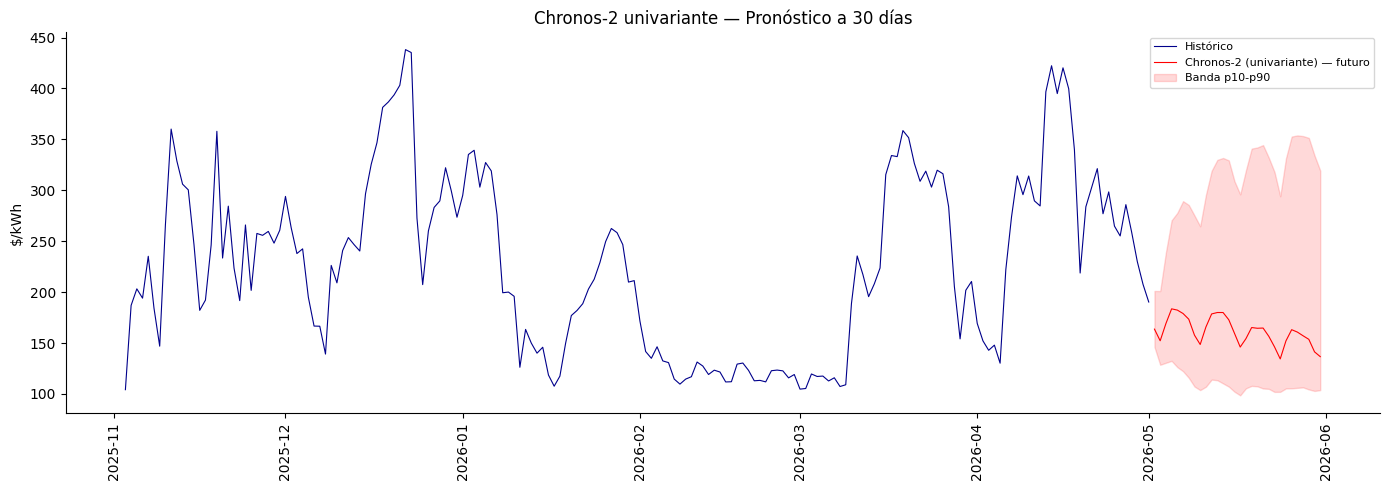

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[-180:], df['precio_bolsa'][-180:], color='darkblue', linewidth=0.8, label='Histórico')
ax.plot(df_forecast_futuro.index, df_forecast_futuro['Punto'], color='red', linewidth=0.8, label='Chronos-2 (univariante) — futuro')
ax.fill_between(df_forecast_futuro.index, df_forecast_futuro['p10'], df_forecast_futuro['p90'],
                 color='red', alpha=0.15, label='Banda p10-p90')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title(f'Chronos-2 univariante — Pronóstico a {horizonte_futuro} días')
sns.despine()
plt.tight_layout()
plt.show()

## Con covariables:

In [15]:
covariables_futuras = {}

for col in covariables:
    ctx_col = df[[col]].reset_index().assign(id=col)
    pred_col = pipeline.predict_df(
        ctx_col,
        prediction_length=horizonte_futuro,
        quantile_levels=[0.5],
        id_column="id",
        timestamp_column="timestamp",
        target=col,
    ).set_index("timestamp")
    covariables_futuras[col] = pred_col["predictions"]
    print(f"{col}: proyectado {horizonte_futuro} días hacia adelante")

df_covariables_futuras = pd.DataFrame(covariables_futuras)
print(df_covariables_futuras)

gen_termica: proyectado 30 días hacia adelante
ONI: proyectado 30 días hacia adelante
aportes_energia_gwh: proyectado 30 días hacia adelante
            gen_termica       ONI  aportes_energia_gwh
timestamp                                             
2026-05-02   25672672.0  0.841235          761198528.0
2026-05-03   23840778.0  0.845799          770315520.0
2026-05-04   26211552.0  0.837227          786417728.0
2026-05-05   28375464.0  0.833380          788966400.0
2026-05-06   29000472.0  0.829325          787659904.0
2026-05-07   29078080.0  0.827704          793844480.0
2026-05-08   28313744.0  0.829524          795274752.0
2026-05-09   25867140.0  0.826314          805683584.0
2026-05-10   24480756.0  0.827073          803868096.0
2026-05-11   26598964.0  0.832868          809333568.0
2026-05-12   28189730.0  0.832548          812897152.0
2026-05-13   29134768.0  0.833216          815605504.0
2026-05-14   29223760.0  0.832396          814277376.0
2026-05-15   28555868.0  0.839643 

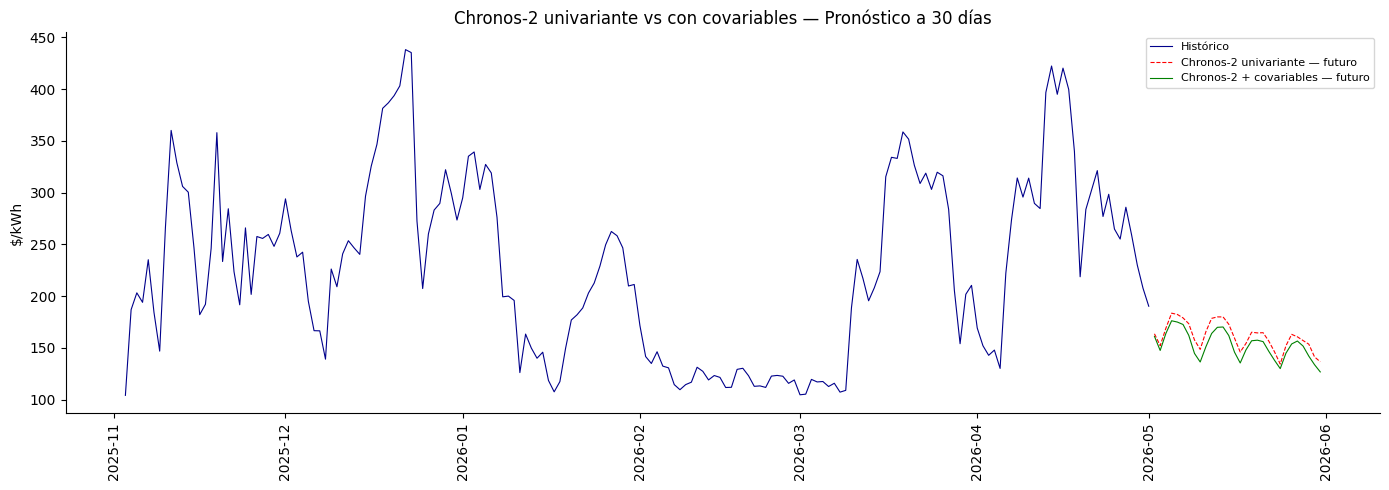

            univariante  con_covariables
timestamp                               
2026-05-02   163.655182       161.177185
2026-05-03   152.213455       147.554443
2026-05-04   169.079193       164.046021
2026-05-05   183.565338       176.226517
2026-05-06   182.349426       174.995972
2026-05-07   178.990631       172.635147
2026-05-08   173.399048       162.132111
2026-05-09   157.718704       144.694153
2026-05-10   148.564438       136.420380
2026-05-11   165.735977       151.170013
2026-05-12   178.560425       163.945557
2026-05-13   179.959946       169.894348
2026-05-14   179.953079       170.223282
2026-05-15   172.854721       161.958344
2026-05-16   159.488983       145.909882
2026-05-17   146.039429       135.469879
2026-05-18   154.292267       148.059723
2026-05-19   165.207840       156.917572
2026-05-20   164.496185       157.482483
2026-05-21   164.715576       156.093735
2026-05-22   156.597748       146.702820
2026-05-23   146.212433       138.055450
2026-05-24   134

In [16]:
context_df_futuro_cov = (
    df[['precio_bolsa'] + covariables]
    .reset_index()
    .assign(id=ID_SERIE)
)

future_df_futuro_cov = (
    df_covariables_futuras
    .reset_index()
    .rename(columns={'index': 'timestamp'})
    .assign(id=ID_SERIE)
)

pred_df_futuro_cov = pipeline.predict_df(
    context_df_futuro_cov,
    future_df=future_df_futuro_cov,
    prediction_length=horizonte_futuro,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target="precio_bolsa",
).set_index("timestamp")

pred_futuro_cov = pred_df_futuro_cov["predictions"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[-180:], df['precio_bolsa'][-180:], color='darkblue', linewidth=0.8, label='Histórico')
ax.plot(df_forecast_futuro.index, df_forecast_futuro['Punto'], color='red', linewidth=0.8, linestyle='--', label='Chronos-2 univariante — futuro')
ax.plot(pred_futuro_cov.index, pred_futuro_cov, color='green', linewidth=0.8, label='Chronos-2 + covariables — futuro')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title(f'Chronos-2 univariante vs con covariables — Pronóstico a {horizonte_futuro} días')
sns.despine()
plt.tight_layout()
plt.show()

print(pd.DataFrame({'univariante': df_forecast_futuro['Punto'], 'con_covariables': pred_futuro_cov}))